# 02 - Churn & Retention

Cohort retention, RFM segments, and a churn-prediction model.

In [1]:
import sys; sys.path.append('../src')
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
from data_prep import clean_transactions, summarize
sns.set_theme(style='whitegrid'); plt.rcParams['figure.figsize']=(10,5)
from features import cohort_matrix, build_rfm, churn_labels

In [2]:
# Load raw data (after placing online_retail_II.xlsx in ../data/raw/)
raw = pd.read_excel('../data/raw/online_retail_II.xlsx', sheet_name=None)
df = pd.concat(raw.values(), ignore_index=True)
df = clean_transactions(df)
summarize(df)

{'rows': 805549,
 'customers': 5878,
 'invoices': 36969,
 'first_order': Timestamp('2009-12-01 07:45:00'),
 'last_order': Timestamp('2011-12-09 12:50:00'),
 'total_revenue': np.float64(17743429.18)}

## Cohort retention heatmap

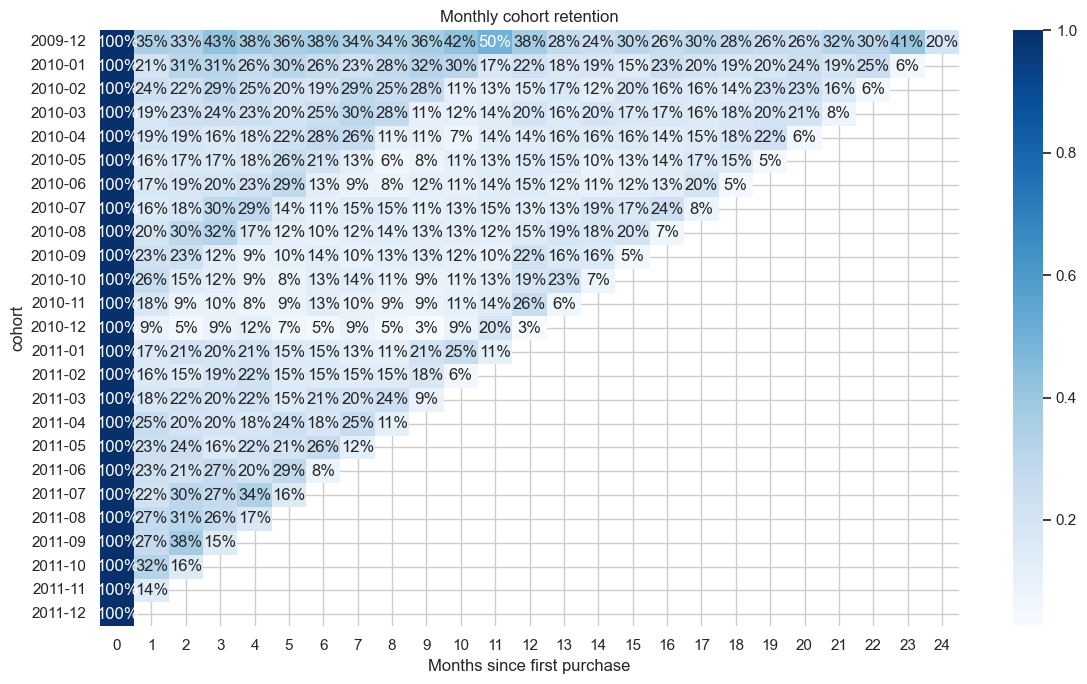

In [3]:
mat = cohort_matrix(df)
plt.figure(figsize=(12,7))
sns.heatmap(mat, annot=True, fmt='.0%', cmap='Blues')
plt.title('Monthly cohort retention'); plt.xlabel('Months since first purchase')
plt.tight_layout(); plt.savefig('../reports/figures/cohort_retention.png', dpi=120)

## RFM segments

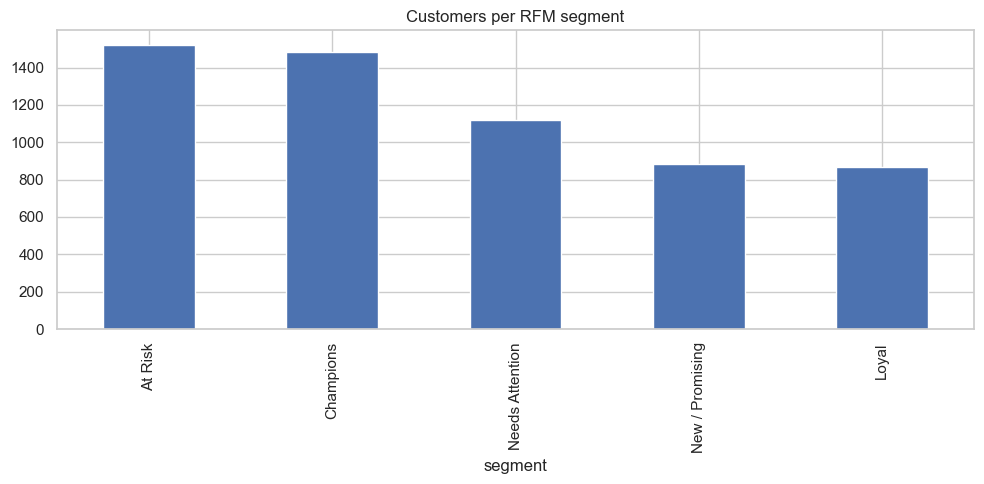

In [4]:
rfm = build_rfm(df)
rfm['segment'].value_counts().plot.bar(title='Customers per RFM segment')
plt.tight_layout()

## Churn model (XGBoost with logistic-regression fallback)

**Note:** churn is defined as no purchase in the last 90 days, which is a function of recency. We therefore *exclude* recency-derived features (`r_score`) and predict churn from purchasing behaviour only (frequency, monetary). This avoids target leakage and gives a more defensible AUC.

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report

data = churn_labels(df, inactive_days=90)
# exclude recency-derived features to avoid leakage with the churn definition
X = data[['frequency','monetary','f_score','m_score']]
y = data['churned']
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

try:
    from xgboost import XGBClassifier
    model = XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05,
                          subsample=0.9, eval_metric='logloss', random_state=42)
except ImportError:
    from sklearn.linear_model import LogisticRegression
    model = LogisticRegression(max_iter=1000)

model.fit(Xtr, ytr)
proba = model.predict_proba(Xte)[:,1]
print('AUC:', round(roc_auc_score(yte, proba), 3))
print(classification_report(yte, (proba>0.5).astype(int)))

AUC: 0.765
              precision    recall  f1-score   support

           0       0.72      0.66      0.69       722
           1       0.70      0.75      0.72       748

    accuracy                           0.71      1470
   macro avg       0.71      0.71      0.71      1470
weighted avg       0.71      0.71      0.71      1470



> **Next:** `03_sales_revenue.ipynb`